<a href="https://colab.research.google.com/github/ankitkparashar/python/blob/main/CSML/Module3/DecisionTreeandOptimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [2]:
df_clf = DecisionTreeClassifier(random_state=156)
iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.2, random_state=11)
df_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=156)

In [3]:
import pandas as pd
iris_df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
iris_df['label'] = iris_data.target
iris_df['label'].value_counts()

,count
label,
0,50
1,50
2,50


In [5]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
from sklearn.tree import export_graphviz
export_graphviz(df_clf, out_file='tree.dot', class_names=iris_data.target_names, feature_names=iris_data.feature_names, impurity=True, filled=True)

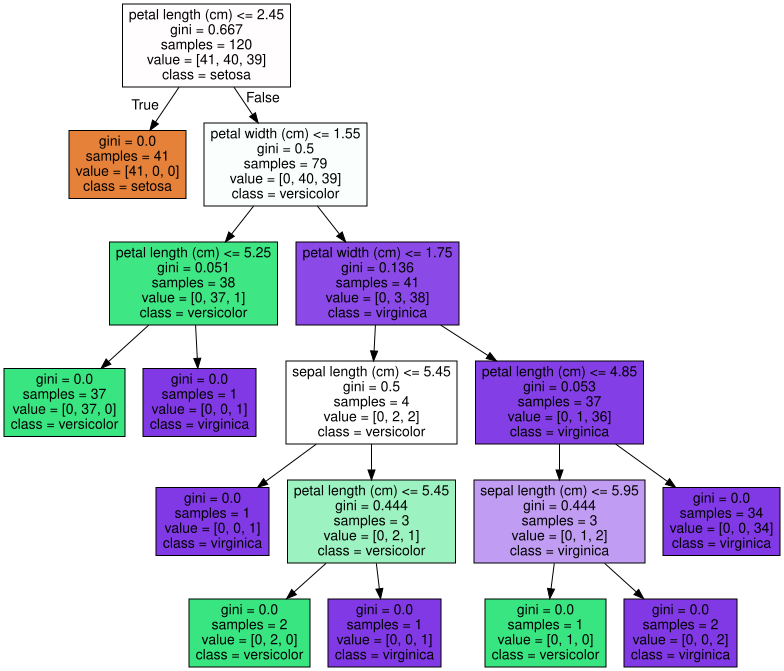

In [7]:
import graphviz
with open('tree.dot') as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [9]:
print("Feature Importance")
print(df_clf.feature_importances_)

Feature Importance
[0.02500521 0.         0.55490281 0.42009198]


In [10]:
for name, score in zip(iris_data.feature_names, df_clf.feature_importances_):
    print(name, score)

sepal length (cm) 0.02500520941862888
sepal width (cm) 0.0
petal length (cm) 0.5549028149313102
petal width (cm) 0.42009197565006084


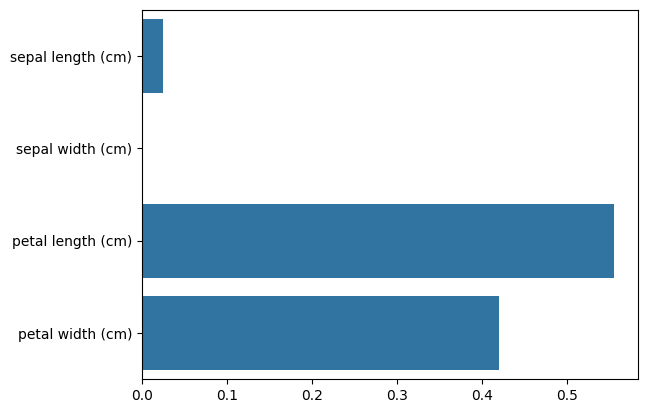

In [11]:
sns.barplot(x=df_clf.feature_importances_, y=iris_data.feature_names)
plt.show()

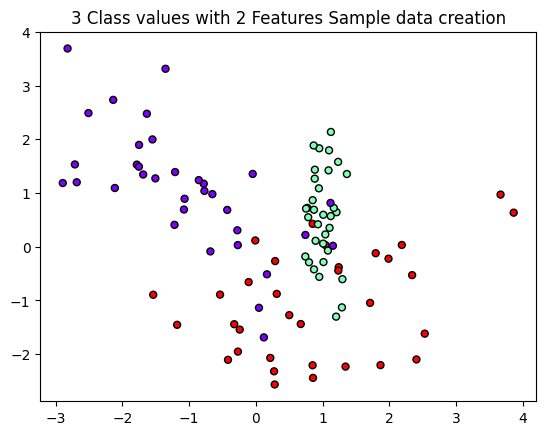

In [16]:
from sklearn.datasets import make_classification

plt.title("3 Class values with 2 Features Sample data creation")
X, y = make_classification(n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1, n_classes=3, random_state=0)
plt.scatter(X[:, 0], X[:, 1], marker='o', c=y, s=25, cmap='rainbow', edgecolor='k')
plt.show()

In [17]:
def visualize_boundary(model, X, y):
    fig, ax = plt.subplots()

    # 학습 데
    ax.scatter(X[:, 0], X[:, 1], c=y, s=25, cmap='rainbow', edgecolor='k',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim_start, xlim_end = ax.get_xlim()
    ylim_start, ylim_end = ax.get_ylim()

    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(xlim_start, xlim_end, num=200),
                         np.linspace(ylim_start, ylim_end, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5, cmap='rainbow', clim=(y.min(), y.max()),
                           zorder=1)

    ax.set(xlim=(xlim_start, xlim_end), ylim=(ylim_start, ylim_end))
    plt.show()


/tmp/ipython-input-902645155.py:18: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


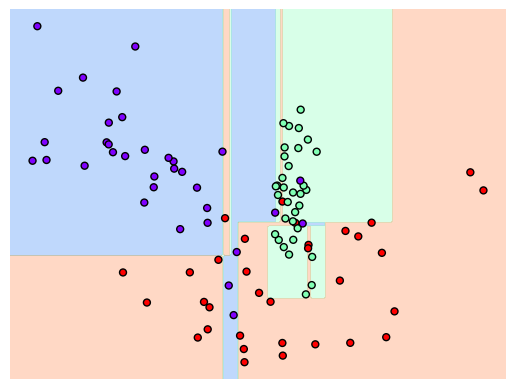

In [18]:
df_clf = DecisionTreeClassifier(random_state=0).fit(X, y)
visualize_boundary(df_clf, X, y)

/tmp/ipython-input-902645155.py:18: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


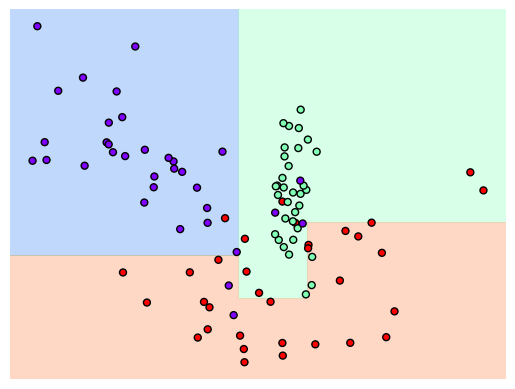

In [19]:
df_clf = DecisionTreeClassifier(min_samples_leaf=6).fit(X, y)
visualize_boundary(df_clf, X, y)

/tmp/ipython-input-902645155.py:18: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


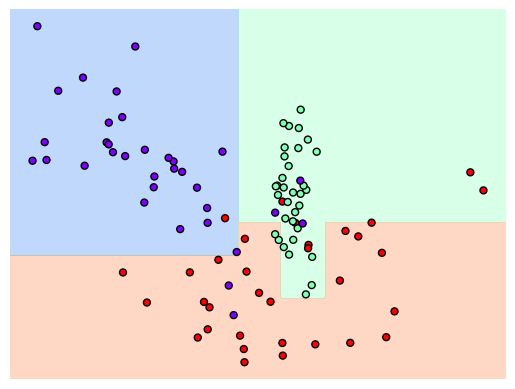

In [20]:
df_clf = DecisionTreeClassifier(min_samples_leaf=5).fit(X, y)
visualize_boundary(df_clf, X, y)

/tmp/ipython-input-902645155.py:18: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


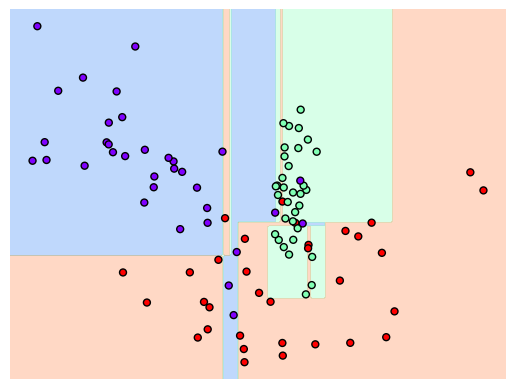

In [21]:
df_clf = DecisionTreeClassifier(min_samples_leaf=1).fit(X, y)
visualize_boundary(df_clf, X, y)